In [2]:
import gymnasium as gym
import numpy as np
from matplotlib import pyplot as plt
from envs.register import register_envs
register_envs()

from learners import Qlearning, QuantileRegression
from explorers import EpsilonGreedy
from dist_run import *
from policy_util import *
from analysis import *

params = Params(
    model_name="Simple-v1",
    total_episodes=100_000,
    save_skip=100,
    n_runs=1,
    seed=123,
    
    lr_decay=2000,
    learning_rate=1.0,

    gamma=1.0,
    epsilon=1.0,
    huber_k=1.0,
    n_quantiles=32,
    
    action_size=None,
    state_size=None,
    map_size=None,
    
    learner_name=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.n_quantiles) + 0.5) / params.n_quantiles

env = gym.make(params.model_name)
env.action_space.seed(params.seed)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
params = params._replace(map_size=env.unwrapped.shape)

env.reset()
s_init = env.unwrapped.s

learner = QuantileRegression(params)
if isinstance(learner, Qlearning): params = params._replace(n_quantiles=1)
if params.learner_name is None:
    params = params._replace(learner_name=str(learner).split(".")[1].split(" ")[0])

In [114]:
# random_policy = np.ones((params.state_size, params.action_size))
# returns = MonteCarlo(env, random_policy, params, 4, rng, total_episodes=500_000)

In [3]:
learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables_run = run_env(env, learner, explorer, params, show_progress=False)

tables = tables_run.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]

Run 0/1 - Episodes: 100%|██████████| 100000/100000 [00:03<00:00, 29734.75it/s]


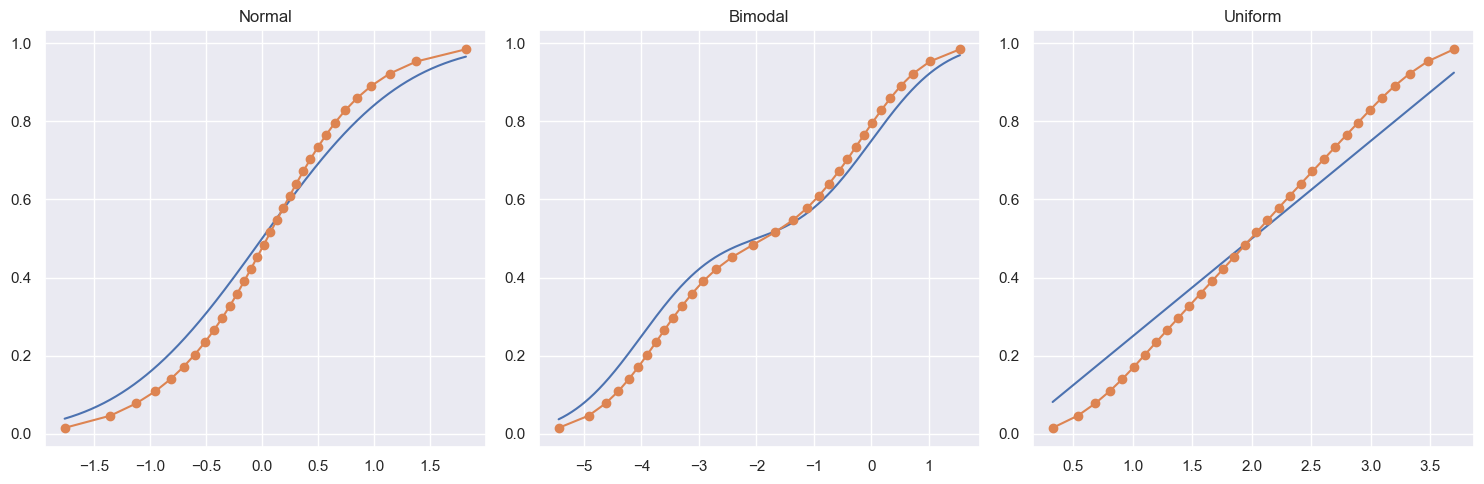

In [4]:
from matplotlib import pyplot as plt
import scipy.stats as stats
import numpy as np

normal = lambda x : stats.norm.cdf(x, 0, 1)
bimodal = lambda x : 0.5 * stats.norm.cdf(x, -4, 1) + 0.5 * stats.norm.cdf(x, 0, 1)
uniform = lambda x : np.where(x < 0, 0, np.where(x <= 4, 0.25 * x, 1))

quantiles = tables[-1, 4]
funcs = [normal, bimodal, uniform]
names = ["Normal", "Bimodal", "Uniform"]

plt.figure(figsize=(15,5))
for i in range(len(quantiles)):
    plt.subplot(1, 3, i+1)
    q = quantiles[i]
    x = np.linspace(q.min(), q.max(), 1000)
    plt.plot(x, funcs[i](x))
    plt.plot(q, tau, marker="o")
    plt.title(names[i])
plt.tight_layout()
plt.show()

In [1335]:
def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))
N = 32
theta = np.ones(N)/N
lr = 1.0

In [1]:
this_theta = theta.copy()

for _ in range(10_000):
    pred_quantiles = this_theta
    target_quantiles = (np.random.normal(-4) if np.random.rand() < 0.5 else np.random.normal(0)) + np.zeros(N)
    u = target_quantiles[None, :] - pred_quantiles[:, None]
    rho = -np.abs(tau[:, None] - (u < 0).astype(float)) * du_huber(u, k=1.0)
    this_theta -= lr * rho.mean(1)

plt.figure(figsize=(5,5))
x = np.linspace(-6, 2, 1000)
plt.plot(x, bimodal(x))
plt.plot(this_theta, tau, marker="o")
plt.plot(theta, tau, marker="o")
plt.xlim(x.min(),x.max())
plt.tight_layout()
plt.show()

theta = this_theta
lr *= 0.5

NameError: name 'theta' is not defined

In [1355]:
import numpy as np
import matplotlib.pyplot as plt

def du_huber(u, k=1.0):
    """Derivative of Huber loss"""
    return np.where(np.abs(u) <= k, u, k * np.sign(u))

# Setup
N = 512
tau = np.linspace(0, 1, N)  # Quantile levels from 0 to 1
theta = np.zeros(N)  # Initialize quantiles (start at 0)

lr = 0.01  # Lower learning rate for stability
batch_size = 32  # Use mini-batches

# Training loop
losses = []
for iteration in range(20_000):
    # Sample from the true bimodal distribution
    samples = np.array([
        np.random.normal(-4, 1) if np.random.rand() < 0.5 else np.random.normal(0, 1)
        for _ in range(batch_size)
    ])
    
    # Compute quantile regression loss for each sample
    gradients = np.zeros(N)
    for sample in samples:
        # Compute residuals: y - quantile_prediction
        u = sample - theta
        
        # Quantile regression gradient
        # grad = -(tau - I(u < 0)) * du_huber(u)
        indicator = (u < 0).astype(float)
        grad = -np.abs(tau - indicator) * du_huber(u, k=1.0)
        gradients += grad
    
    # Average gradient over batch
    gradients /= batch_size
    
    # Update quantiles
    theta -= lr * gradients
    
    # Track loss (optional)
    if iteration % 100 == 0:
        loss = np.mean([
            np.sum(np.where(samples[:, None] >= theta, 
                           tau * (samples[:, None] - theta),
                           (tau - 1) * (samples[:, None] - theta)))
            for _ in range(10)
        ])
        losses.append(loss)

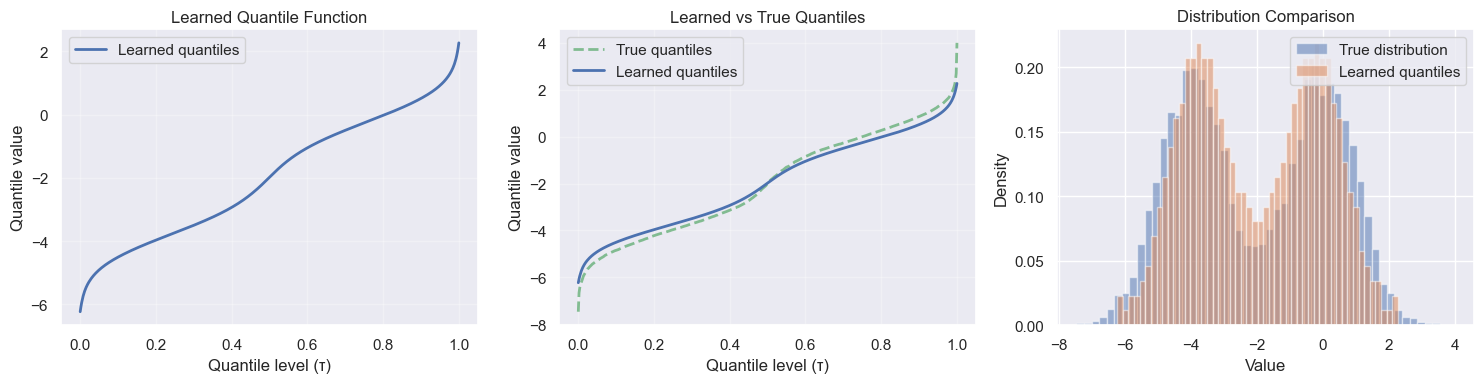

Learned quantiles: [-6.23015806e+00 -6.07346074e+00 -5.94110552e+00 -5.82927358e+00
 -5.73417346e+00 -5.65195711e+00 -5.58064276e+00 -5.51773103e+00
 -5.46138840e+00 -5.41047737e+00 -5.36414900e+00 -5.32152725e+00
 -5.28197152e+00 -5.24484324e+00 -5.20987089e+00 -5.17696995e+00
 -5.14583798e+00 -5.11624843e+00 -5.08810073e+00 -5.06116455e+00
 -5.03540150e+00 -5.01058358e+00 -4.98665982e+00 -4.96357954e+00
 -4.94120765e+00 -4.91953015e+00 -4.89856122e+00 -4.87825564e+00
 -4.85854760e+00 -4.83940825e+00 -4.82077907e+00 -4.80263161e+00
 -4.78490896e+00 -4.76755926e+00 -4.75063274e+00 -4.73406873e+00
 -4.71786950e+00 -4.70200111e+00 -4.68647054e+00 -4.67123168e+00
 -4.65621393e+00 -4.64144533e+00 -4.62689381e+00 -4.61254088e+00
 -4.59837832e+00 -4.58443353e+00 -4.57067743e+00 -4.55713409e+00
 -4.54379801e+00 -4.53064131e+00 -4.51766053e+00 -4.50485198e+00
 -4.49221519e+00 -4.47972644e+00 -4.46739773e+00 -4.45520648e+00
 -4.44311723e+00 -4.43112751e+00 -4.41924771e+00 -4.40747633e+00
 -4.39

In [1356]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Learned quantiles
axes[0].plot(tau, theta, 'b-', linewidth=2, label='Learned quantiles')
axes[0].set_xlabel('Quantile level (τ)')
axes[0].set_ylabel('Quantile value')
axes[0].set_title('Learned Quantile Function')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Compare with true distribution
true_samples = np.array([
    np.random.normal(-4, 1) if np.random.rand() < 0.5 else np.random.normal(0, 1)
    for _ in range(10000)
])
true_quantiles = np.quantile(true_samples, tau)

axes[1].plot(tau, true_quantiles, 'g--', linewidth=2, label='True quantiles', alpha=0.7)
axes[1].plot(tau, theta, 'b-', linewidth=2, label='Learned quantiles')
axes[1].set_xlabel('Quantile level (τ)')
axes[1].set_ylabel('Quantile value')
axes[1].set_title('Learned vs True Quantiles')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot 3: Distribution comparison
axes[2].hist(true_samples, bins=50, density=True, alpha=0.5, label='True distribution')
axes[2].hist(theta, bins=50, density=True, alpha=0.5, label='Learned quantiles')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Density')
axes[2].set_title('Distribution Comparison')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Learned quantiles: {theta}")
print(f"True quantiles (approx): {true_quantiles}")
print(f"Mean absolute error: {np.mean(np.abs(theta - true_quantiles)):.4f}")

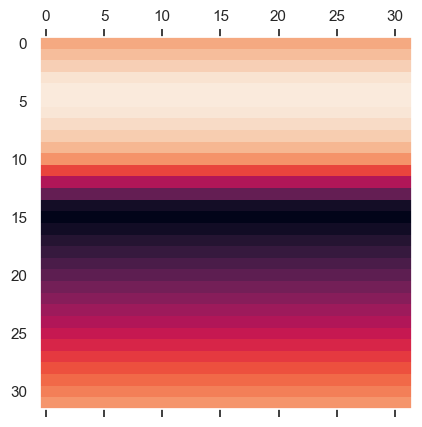

In [1283]:
rando = lambda: (np.random.normal(-4) if np.random.rand() < 0.5 else np.random.normal(0)) + np.zeros(N)

r = rando()
u = r[None, :] - this_theta[:, None]
rho = -np.abs(tau[:, None] - (u < 0))# * du_huber(u, k=1.0)

rho.mean(1)

res = abs(tau[:, None] - (u < 0).astype(float)) * du_huber(u, k=1.0)
plt.matshow(res)
plt.grid()

In [20]:
from tqdm import tqdm

env = gym.make(params.model_name)
total_rewards = []

for episode in tqdm(range(200_000)):
    state, _ = env.reset()
    done = False
    total_reward = 0
    discount = 1.0

    while not done:
        action = np.random.randint(0, params.action_size)
        next_state, reward, terminated, truncated, _ = env.step(action)

        total_reward += discount * reward
        discount *= params.gamma

        state = next_state
        done = terminated or truncated

    total_rewards.append(total_reward)
total_rewards.sort()
total_rewards = np.array(total_rewards)

100%|██████████| 200000/200000 [00:01<00:00, 177167.94it/s]


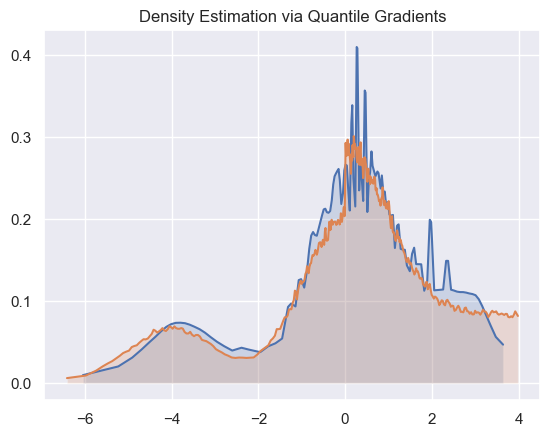

In [37]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme()

arrow_directions = {0: "↑", 1: "→", 2: "↓", 3: "←"}

def plot_grad(quantiles, is_filled=True):
    r = quantiles.reshape(-1)
    r.sort()
    tau = (np.arange(len(r)) + 0.5) / len(r)
    plt.plot(r, np.gradient(tau, r))
    if is_filled:
        plt.fill_between(r, np.gradient(tau, r), alpha=0.2)
    plt.title("Density Estimation via Quantile Gradients")


r = quantiles.reshape(-1)
r.sort()
tau = (np.arange(len(r)) + 0.5) / len(r)
# plt.hist(r, bins=80);
plot_grad(r[::3][::1])
plot_grad(total_rewards[(tau*len(total_rewards)).round().astype(int)][::1])

# plt.plot(total_rewards[(tau*len(total_rewards)).round().astype(int)]);

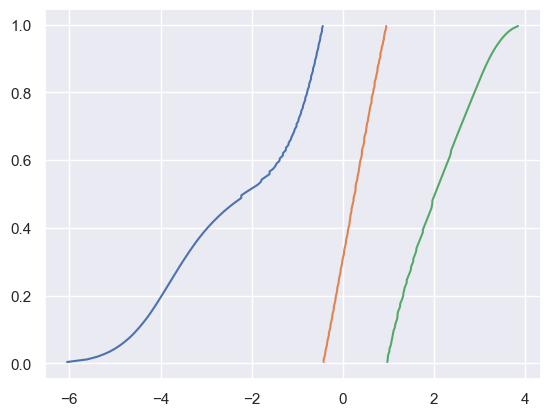

In [47]:
for q in quantiles:
    tau = (np.arange(len(q)) + 0.5) / len(q)
    plt.plot(q, tau)